# 1. Imports


In [13]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split

import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import apply_affine_transform

# 2. Setting Up the Dataset Path

In [14]:
print(os.getcwd())
BASE_DIR = os.getcwd()
DATADIR = os.path.join(BASE_DIR, "dataset")


c:\Users\habib\Kidney_stone_detection-


 # 3. Preview One Image Per Category

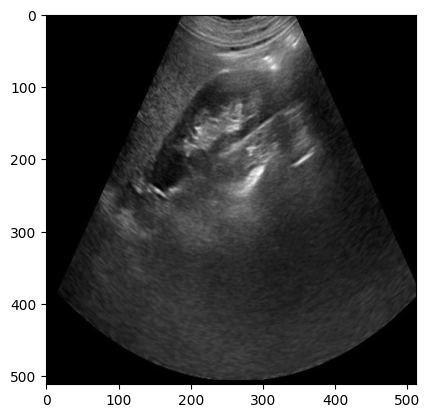

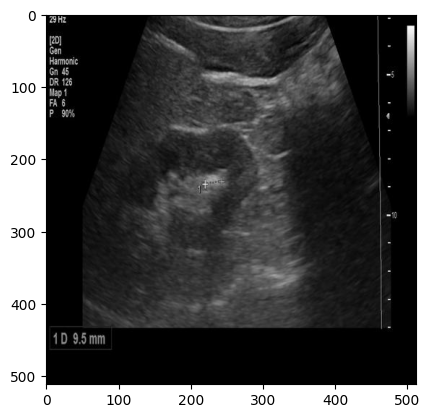

In [15]:

CATEGORIES = ["Normal", "stone"]  # Normal=0, stone=1
for category in CATEGORIES:
    path = os.path.join(DATADIR, category)
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
        plt.imshow(img_array, cmap="gray")
        plt.show()
        break

# 4. Resize the Image

Original Image shape: (512, 512)
Resized Image shape: (225, 225)


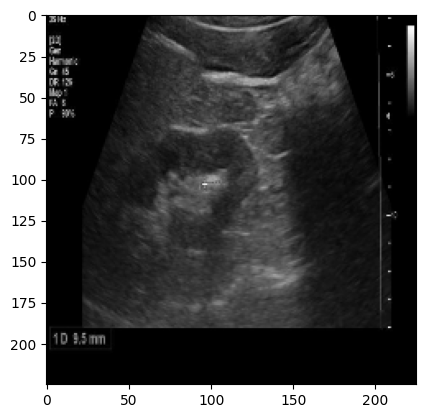

In [16]:
print("Original Image shape:", img_array.shape)  # original size
IMG_SIZE = 225
new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
plt.imshow(new_array, cmap="gray")
print("Resized Image shape:", new_array.shape)  # resized image
plt.show()

# 5. Build the Training Dataset

In [17]:
training_data = []
def create_training_data():
    for category in CATEGORIES:
        path = os.path.join(DATADIR, category)
        class_num = CATEGORIES.index(category) # stone=0, Normal=1
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                training_data.append([new_array, class_num])
            except Exception as e:
                print(f"Error processing image {img}: {e}")

create_training_data()
print(len(training_data))  # total number of images loaded

2000


#  6. Shuffle & Separate Features/Labels

In [18]:
random.shuffle(training_data)   # prevents the model from learning order

X = []  # features (images)
y = []  # labels (0 or 1)

for feature, label in training_data:
    X.append(feature)
    y.append(label)

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y = np.array(y)

# 7. Save with Pickle
##### Pickle saves Python objects to disk so you don't re-process images every time

In [19]:
import pickle

# Save X (images)
pickle_out = open("X.pickle", "wb")   # "wb" = write binary
pickle.dump(X, pickle_out)
pickle_out.close()

# Save y (labels)
pickle_out = open("y.pickle", "wb")
pickle.dump(y, pickle_out)
pickle_out.close()

# 8. Load Pickle Back

In [20]:
pickle_in = open("X.pickle", "rb")   # "rb" = read binary
X = pickle.load(pickle_in)

pickle_in = open("y.pickle", "rb")
y = pickle.load(pickle_in)

# 9. Normalize the Images


In [21]:
X = X / 255.0

# 10. Split Dataset into Training, Validation& Testing (70,15,15)

In [22]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training data shape:", X_train.shape)
print("Validation data shape:", X_val.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1400, 225, 225, 1)
Validation data shape: (300, 225, 225, 1)
Testing data shape: (300, 225, 225, 1)


 # 11. Data Augmentation

In [23]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# 12. Visualize Augmented Images

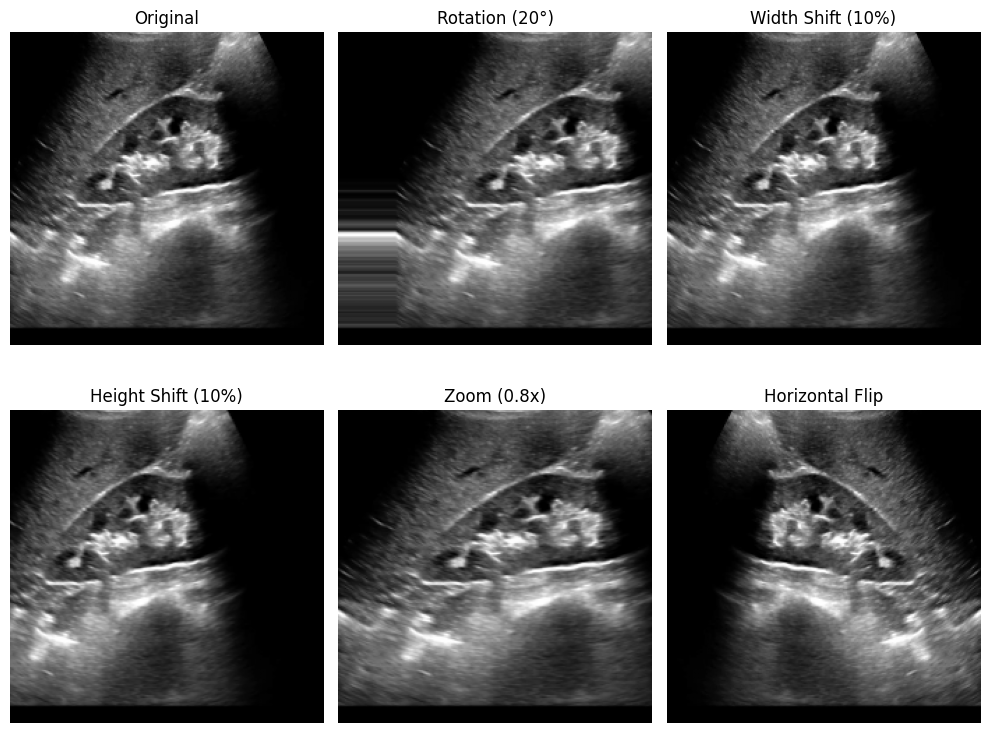

In [24]:
img = X_train[0]  # shape = (225, 225, 1)

plt.figure(figsize=(10,8))

# Original
plt.subplot(2,3,1)
plt.imshow(img.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.title("Original")
plt.axis("off")

# Rotation
rot = apply_affine_transform(img, theta=20)
plt.subplot(2,3,2)
plt.imshow(rot.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.title("Rotation (20°)")
plt.axis("off")

# Width shift (horizontal)
width_shift = apply_affine_transform(img, tx=IMG_SIZE * 0.1)
plt.subplot(2,3,3)
plt.imshow(width_shift.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.title("Width Shift (10%)")
plt.axis("off")

# Height shift (vertical)
height_shift = apply_affine_transform(img, ty=IMG_SIZE * 0.1)
plt.subplot(2,3,4)
plt.imshow(height_shift.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.title("Height Shift (10%)")
plt.axis("off")

# Zoom
zoom = apply_affine_transform(img, zx=0.8, zy=0.8)
plt.subplot(2,3,5)
plt.imshow(zoom.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.title("Zoom (0.8x)")
plt.axis("off")

# Flip
flip = np.fliplr(img.reshape(IMG_SIZE, IMG_SIZE))
plt.subplot(2,3,6)
plt.imshow(flip, cmap='gray')
plt.title("Horizontal Flip")
plt.axis("off")

plt.tight_layout()
plt.show()

# 13. Effective Dataset Size After Augmentation

In [25]:
BATCH_SIZE = 32
EPOCHS = 10
steps_per_epoch = len(X_train) // BATCH_SIZE

# Total number of samples the model will "see"
total_seen = steps_per_epoch * BATCH_SIZE * EPOCHS

# How much the dataset is effectively increased
multiplier = total_seen / len(X_train)

print("==== DATASET REPORT ====\n")

print(f"Original TOTAL dataset size: {len(X)}")
print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}\n")

print("---- AUGMENTATION EFFECT ----\n")

print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Steps per epoch: {steps_per_epoch}")

print(f"\nTotal samples seen during training: {total_seen}")
print(f"Effective dataset size increase: {multiplier:.2f}x")

==== DATASET REPORT ====

Original TOTAL dataset size: 2000
Training set size: 1400
Validation set size: 300
Test set size: 300

---- AUGMENTATION EFFECT ----

Batch size: 32
Epochs: 10
Steps per epoch: 43

Total samples seen during training: 13760
Effective dataset size increase: 9.83x
